In [1]:
import torch.nn as nn
import torch

## Change of variable formula

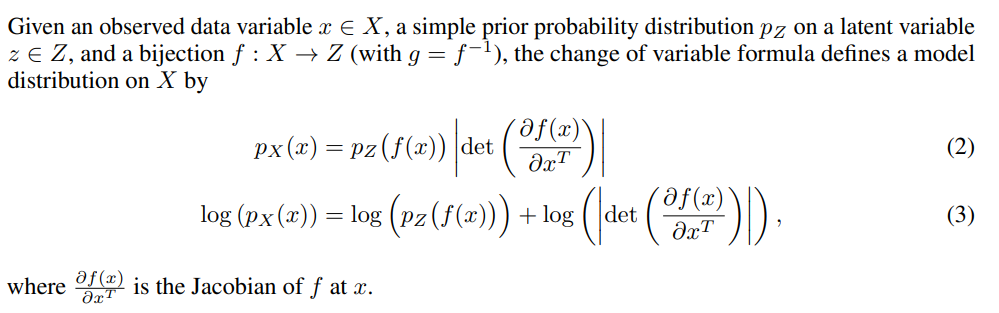

## Coupling Layer

- Computing the Jacobian of functions with high-dimensional domain and codomain and computing
the determinants of large matrices are in general computationally very expensive.

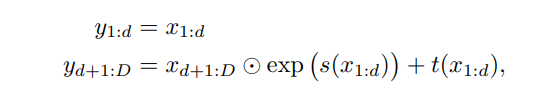

## Properties
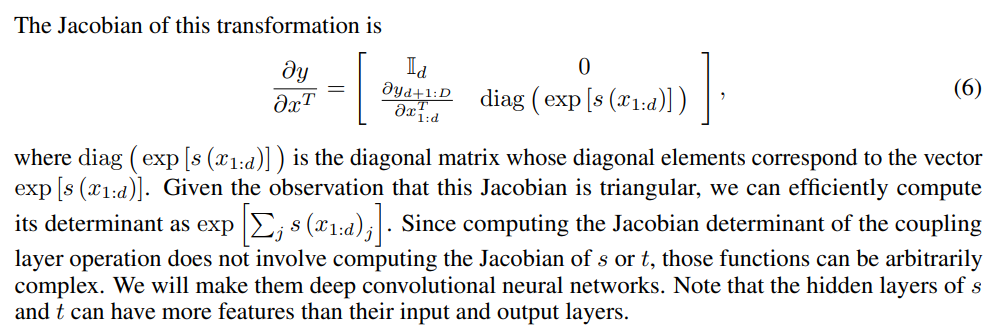

## Masking for Affine Coupling Layers for Image Modelling

#### We use two masking strategy
1. Spatial Checkboard-masking
2. Channel-wise masking

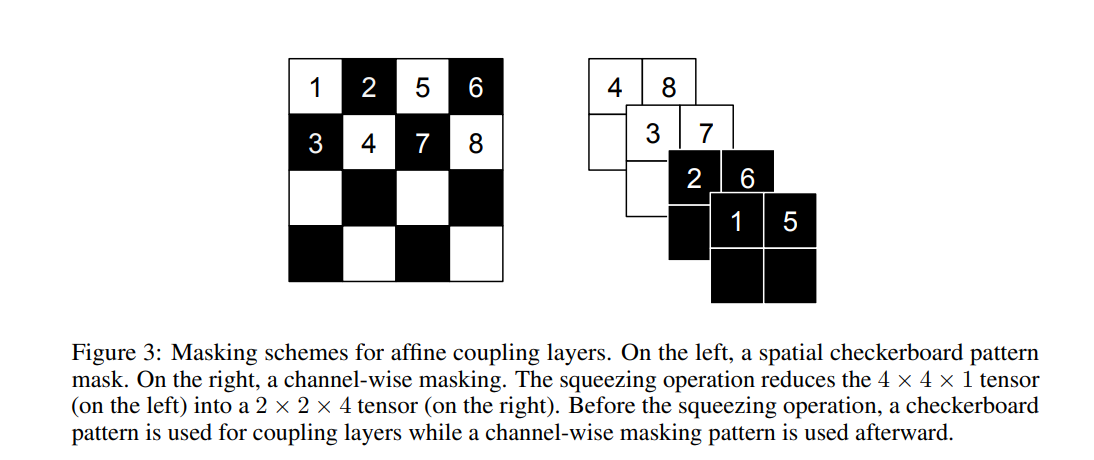

## Masking logic
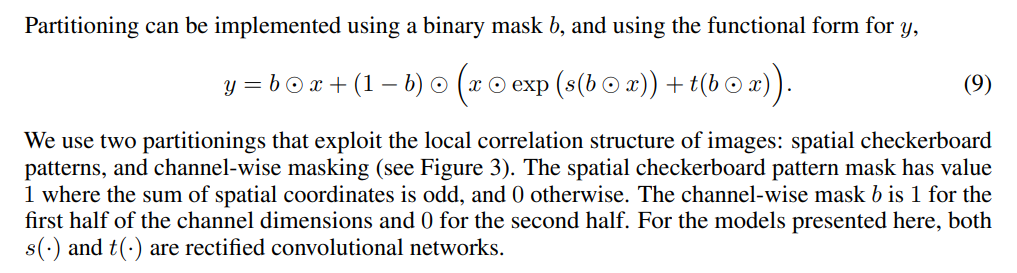

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Implementing these 2 masking techniques

In [3]:
class Masking(nn.Module):
    """
    This class implements 2 masking strategy discussed in this paper: DENSITY ESTIMATION USING REAL NVP
    paper link: https://arxiv.org/pdf/1605.08803

    # 2 types of Masking discussed in the paper was

    1. Check-board pattern masking (applied before the squeezing operator)
    2. Channel-wise masking (applied after the squeezing operator)
    """
    def __init__(self, x: torch.Tensor):
        super().__init__()
        self.x = x

    def forward(self, mask_type: str, first_half: bool | None, device):
        """
        Get the interested masking type, based on 'mask_type' parameter
        if mask_type == channel_wise then parameter 'first_half' needs to be specified
        else 'first_half' must be None
        """
        return self._get_mask(self.x, mask_type = mask_type, first_half = first_half, device = device)
    
    # Check-board masking: we use this masking before the squeezing operator
    def _get_check_board_masking(self, x: torch.Tensor):
        """
        The spatial checkerboard pattern mask has value 1 where the sum of spatial coordinates is odd, and 0 otherwise
        """

        
        # We can also use this, this is slow and not vectorized
        # mask_loop = torch.zeros(x.shape[-2], x.shape[-1])
        # for i in range (x.shape[-2]):
        #     for j in range(x.shape[-1]):
        #         if (i+j) % 2 == 0:
        #             continue
        #         else:
        #             mask_loop[i, j] = 1

        # or, equivalent vectorized masking
        H, W = x.shape[-2], x.shape[-1]

        rows = torch.arange(H).unsqueeze(1) # creates [0, 1, 2, 3, 4, ..., H].T
        cols = torch.arange(W).unsqueeze(0) # creates [0, 1, 2, 3, 4, ..., H]
        # after adding we have all possible sum of pairs of (x, y) coordiantes, then '%2' creates checkerboard pattern
        mask = (rows + cols) % 2
        return mask
    
    # Channel-wise masking: we use this channel wise masking after squeezing operator
    def _get_channel_wise_masking(self, x: torch.Tensor, first_half: bool, device):
        """
        The channel-wise mask b is 1 for the first half of the channel dimensions and 0 for the second half
        if first_half is true then the masking is applied on the 1st half of the channel else the masking is applied on the 2nd half of the channel, maintaining the alternating pattern for masking

        NOTE: channel_wise making dsn't depends on Height, width and batch so we don't need to create the whole masking as (B, C, H, W) and (1, C, H, W) will work as fine and will produce same result when masking is applied
        This works because pytorch automatically handles the broadcasting for us

        Case-1: mask.shape = B, C, H, W and x.shape = B, C, H, W
        mask * x = B, C, H, W

        Case-2: mask.shape = 1, C, 1, 1 and x.shape = B, C, H, W
        mask * x = (1, C, 1, 1) * (B, C, H, W) => (1, C, 1, 1) will be broadcasted to (B, C, H, W) without creating extra memory and then we will get (mask * x = B, C, H, W)

        Both cases will work, but in case-2 will, memory usage is less and training speed will increase
        """
        # we can use this, but for faster training and less memory the 2nd implementation works well

        # Case-1
        # _, C, _, _ = x.shape
        # mask = torch.zeros_like(x)
        # if first_half:
        #     mask[:, :C//2, :, :] = 1
        # else:
        #     mask[:, C//2:, :, :] = 1
        # return mask


        # Case-2
        _, C, _, _ = x.shape
        mask = torch.zeros(1, C, 1, 1, device = device) # Pytorch will handle the broadcasting by its own, we don't need to create torch.zeros_like(x) for masking
        if first_half:
            mask[:, :C//2] = 1
        else:
            mask[:, C//2:] = 1
        return mask
    

    def _get_mask(self, x: torch.Tensor, mask_type: str, first_half: bool | None, device: torch.device):
        if mask_type == "check_board":
            return self._get_check_board_masking(x)
        elif mask_type == "channel_wise" and first_half is not None:
            return self._get_channel_wise_masking(x, first_half, device = device)
        else:
            print("Please select available masking [check_board, channel_wise]")


## Squeezing Operator

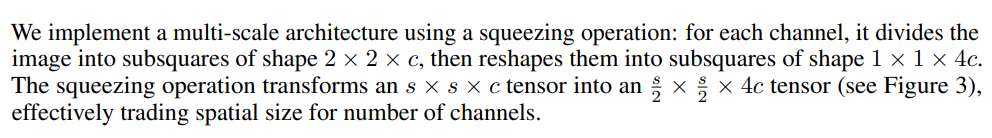

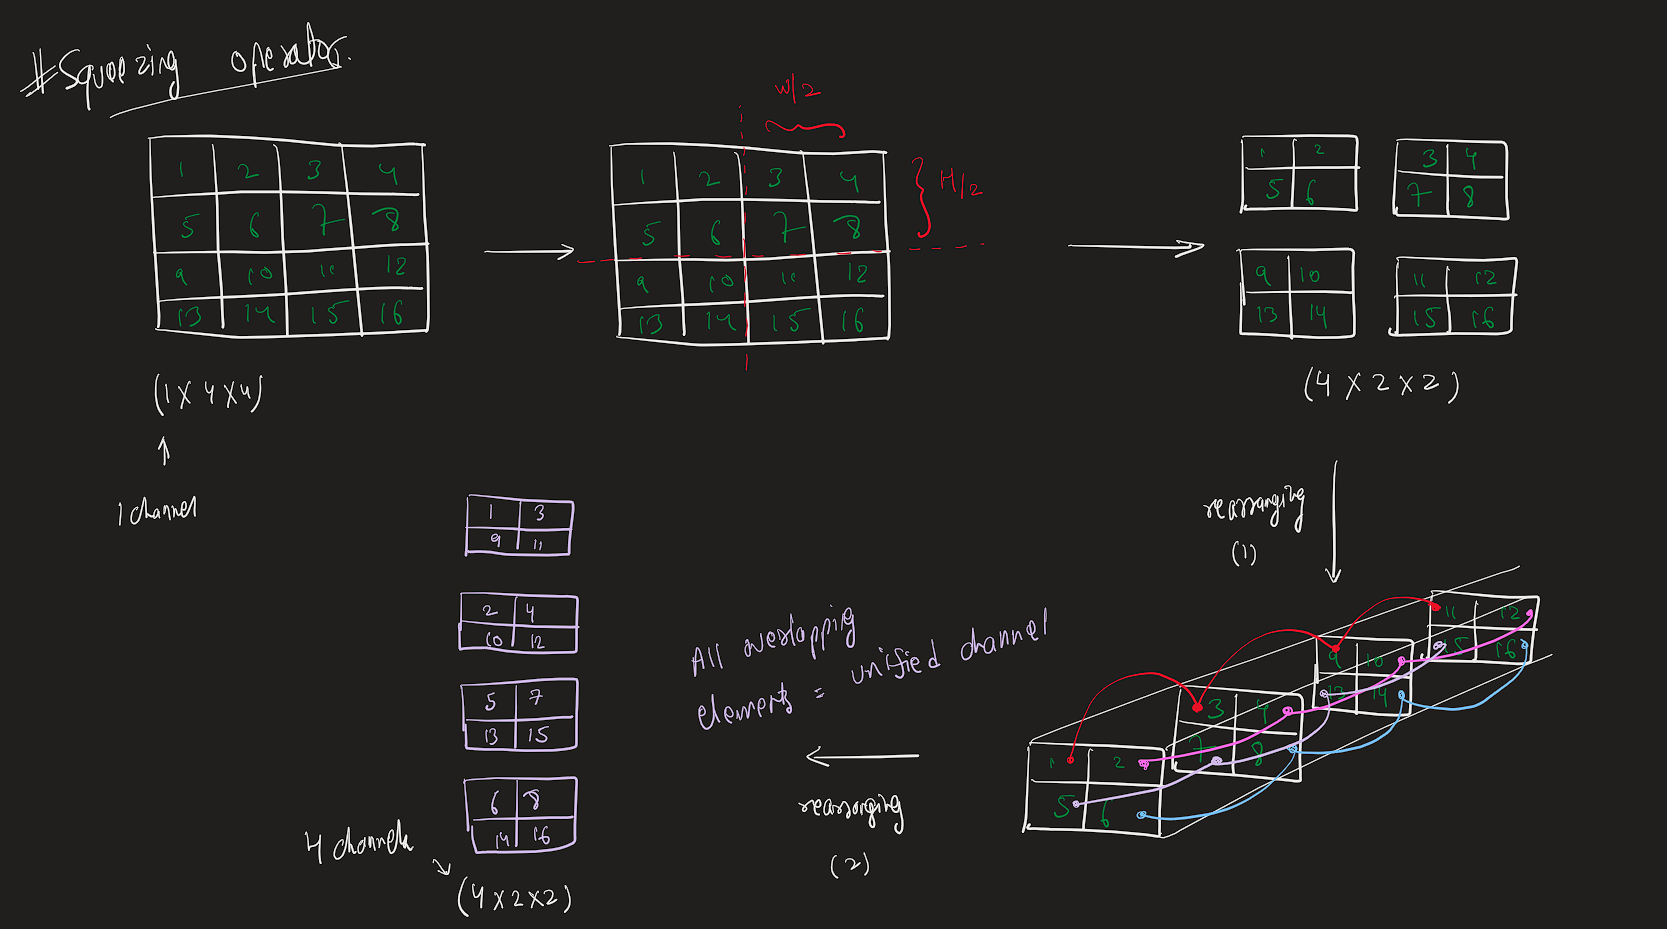

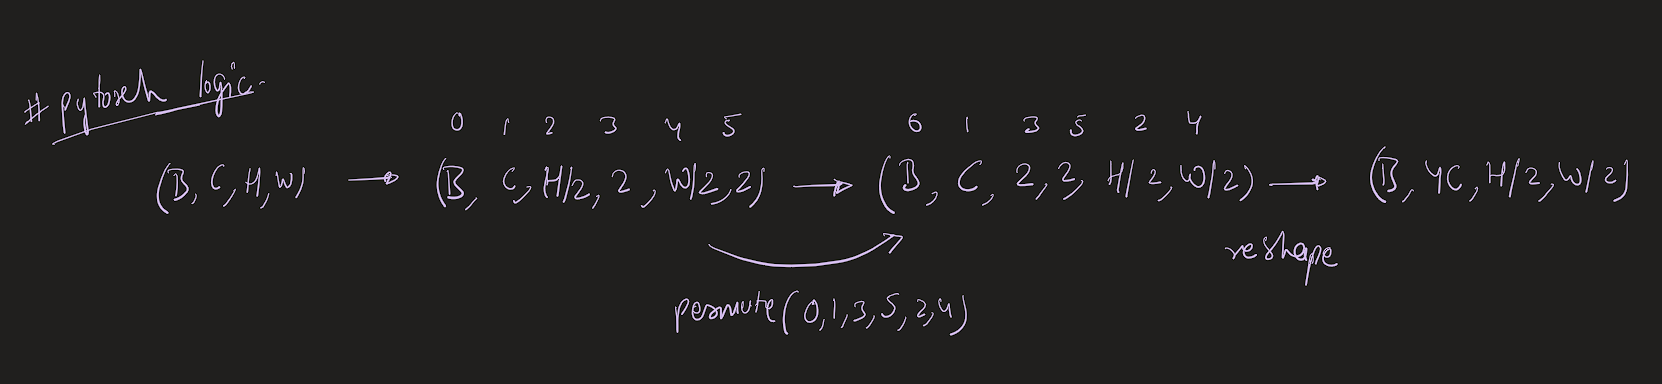

In [4]:
def squeeze(x: torch.Tensor):
    """
    Applies the squeezing operation, mentioned in the paper
    it divides the image into subsquares of shape 2 x 2 x c, then reshapes them into subsquares of shape 1 x 1 x 4c
    
    # Why we squeeze the image?
    1. Squeezing is used to reorganize information so the model can learn dependencies more effectively
    2. without squeezing information spreads slowly across spatial positions
    """
    B, C, H, W = x.shape
    x = x.view(B, C, H//2, 2, W//2, 2) # dividing into subgroups of 2x2
    x = x.permute(0, 1, 3, 5, 2, 4) # bring subgroups of 2x2 near channel-dim
    x = x.reshape(B, 4*C, H//2, W//2)
    return x

## Scale and Shift Neural Network

In [5]:
class ScaleAndShiftNetwork(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x: torch.Tensor):
        """
        get x_a, x_b = mask(x)
        return scale and shift conditioned on x_b, which will be used for the transformation of x_a
        """
        pass


## Batch Normalization

In [6]:
class BatchNormalization(nn.Module):
    """
    Used for Training deep convolutional neural network
    """
    def __init__(self):
        super().__init__()
    
    def forward(self, x: torch.Tensor):
        pass

## Affine Coupling Layer

In [7]:
class AffineCouplingLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor):
        pass

## Residual Skip Connections

In [8]:
class ResidualSkipConnections(nn.Module):
    """
    for efficient gradient flow
    """
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor, function):
        # computes 'x + function(x)'
        pass

## Multi-scale Architecture

In [9]:
class ForwardBlock(nn.Module):
    """
    It first applies three coupling layers (AffineCouplingLayer)
    with alternating checkerboard masks, then perform a squeezing operation, and finally apply three
    more coupling layers with alternating channel-wise masking
    For the final scale, it only applies four coupling layers with alternating checkerboard masks

    Architecture:
        AffineCouplingLayer() x 3 (use alternating checkerboard masking)
        SqueezingOperation()
        AffineCouplingLayer() x 3 (use alternating channel-wise masking)
        AffineCouplingLayer() x 4 (use alternating checkerboard masking)

    """
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor):
        pass

## Model

In [10]:
class RectifiedCNNRNVPModel(nn.Module):
    """
    Stack multiple forward blocks to make deep Rectified Convolutional Neural Network based on Real-valued Non-volume Preserving architecture
    """
    def __init__(self, n_layers: int):
        super().__init__()

    def forward(self, x: torch.Tensor):
        pass

In [11]:
dummy_batch_size = 2
dummy_channel = 4
dummy_height = 32
dummy_width = 32
dummy_x = torch.rand(dummy_batch_size, dummy_channel, dummy_height, dummy_width)

In [12]:
# Get desired masking
mask = Masking(dummy_x)
check_board_mask = mask(mask_type="check_board", first_half=None, device=device)
channel_wise_masking_first_half = mask(mask_type="channel_wise", first_half=True, device=device)
channel_wise_masking_second_half = mask(mask_type="channel_wise", first_half=False, device=device)

In [13]:
check_board_mask

tensor([[0, 1, 0,  ..., 1, 0, 1],
        [1, 0, 1,  ..., 0, 1, 0],
        [0, 1, 0,  ..., 1, 0, 1],
        ...,
        [1, 0, 1,  ..., 0, 1, 0],
        [0, 1, 0,  ..., 1, 0, 1],
        [1, 0, 1,  ..., 0, 1, 0]])

### Completed so far:
1. Understood coupling layers
2. Implemented checkerboard masking
3. Implemented channel-wise masking
4. Understood broadcasting optimization
5. Implemented squeeze operation correctly
6. Designed modular architecture
7. Identified multi-scale factoring but intentionally postponed it

### Todo:
1. Implement Scale and Shift Network (using rectified convolutions)
2. Implement Residual Skip Connections
3. Implement Batch Normalization
4. Implement Affine Coupling Layer
5. Implement Forward Block of the entire network
6. Implement Inverse of this invertible function
7. Implement multi-scale factoring
8. Write training loop and handle dataloading loop
